# Gradient Boosting
Gradient Boosting is another powerful ensemble technique that builds models sequentially, with each new model attempting to correct the errors of the previous ones. It optimizes a loss function and can be more robust to overfitting compared to AdaBoost. Adaboost does not tries to optimize the error, where as Gradient Boosting tries to minimize the error by optimizing a loss function also learnd from previous errors.

### Gradient Boosting Flow
```chart
Dataset -> Train Model 1 -> Test Model 1 -> Calculate Residuals -> Train Model 2 on Residuals -> Test Model 2 -> Calculate New Residuals -> ... -> Final Prediction by Combining All Models
```
```math
F_m(x) = F_0(x) + \gamma T_1(x) + \gamma T_2(x) + ... + \gamma T_m(x)
```
Where: $F_m(x)$ is the final model after m iterations, $F_0(x)$ is the initial model, $T_i(x)$ is the i-th weak learner (e.g., decision tree), and $\gamma$ is the learning rate that controls the contribution of each weak learner.

## Loss Function
In Gradient Boosting, the choice of loss function is crucial as it guides the optimization process. Common loss functions include Mean Squared Error (MSE) for regression tasks and Logarithmic Loss for classification tasks. The model iteratively minimizes this loss function by fitting new models to the residuals of the previous models. Residual means the difference between the actual and predicted values. Fitting new models to the residuals means that each new model is trained to predict the errors made by the previous models, thereby improving the overall accuracy of the ensemble.

```math
L(y, F(x)) = {\frac{1}{2}}\sum_{i=1}^{n} (y_i - F(x_i))^2
```
Where: $L$ is the loss function(MSE), $y$ is the actual value, $F(x)$ is the predicted value, and $n$ is the number of samples.

Now, if we differentiate the loss function with respect to the predictions, we get the gradient, which indicates the direction and magnitude of the steepest ascent. In Gradient Boosting, we use this gradient to update our model iteratively.

```math
\frac{\partial L}{\partial F(x_i)} = F(x_i) - y_i\\
\text{Gradient} = - \frac{\partial L}{\partial F(x_i)} = y_i - F(x_i)
```

What does this negative imply? It implies that to minimize the loss, we need to adjust our predictions in the direction of the negative gradient. In other words, we want to move our predictions closer to the actual values by reducing the errors. If the prediction is too low compared to the actual value, the gradient will be positive, indicating that we need to increase our prediction. Conversely, if the prediction is too high, the gradient will be negative, suggesting that we need to decrease our prediction. It's dimple, we ca understaand it from $y - F(x)$ which is nothing but the residuals. But what does the negative sign indicate here? It indicates that we are moving in the direction that reduces the error between our predictions and the actual values.

Example: Let's say we have a dataset with actual values $y = [3, -0.5, 2, 7]$ and our initial model predictions are $F(x) = [2.5, 0.0, 2, 8]$. The residuals (errors) would be calculated as follows:

$\text{Residuals} = y - F(x) = [3 - 2.5, -0.5 - 0.0, 2 - 2, 7 - 8] = [0.5, -0.5, 0, -1]$





### Gradient Boosting Steps
1. Start prediction with a constant value, often the mean of the target variable.
2. Compute the residuals (errors) between the actual values and the current predictions.
3. Fit a weak learner (e.g., decision tree) to the residuals.
4. Update the predictions by adding the predictions from the weak learner, scaled by a learning rate.
5. Repeat steps 2-4 for a specified number of iterations or until convergence.

Example: Suppose we have a dataset with the following actual values: $y = [3, 5, 7 , 9]$ for $x = [1, 2, 3, 4]$. We start with an initial prediction of the mean value, which is $6$. The residuals are calculated as follows:\
$\text{Residuals} = y - \text{Initial Prediction} = [3 - 6, 5 - 6, 7 - 6, 9 - 6] = [-3, -1, 1, 3]$

We then fit a weak learner (e.g., a decision tree) to these residuals and obtain predictions from this weak learner. For x values the midpoint spilt points are $[1.5,2.5,3.5]$. We choose $2.5$ as the split point. For $x <= 2.5$, the average residual is $(-3 + -1)/2 = -2$ and for $x > 2.5$, the average residual is $(1 + 3)/2 = 2$. 

So, fitting the residual to the next waek learner (let $\gamma = 0.5$) we get the updated predictions as follows:\
Case 1: $x<=2.5$, New Prediction = Initial Prediction + $\gamma$ $\times$ Weak Learner Prediction = $6 + 0.5  -2 = 5$\
Case 2: $x>2.5$, New Prediction = Initial Prediction + $\gamma$ $\times$ Weak Learner Prediction = $6 + 0.5  2 = 7$

Thus, the updated predictions after the first iteration are $[5, 5, 7, 7]$. So the new residuals will be:\
$\text{New Residuals} = y - \text{Updated Predictions} = [3 - 5, 5 - 5, 7 - 7, 9 - 7] = [-2, 0, 0, 2]$

It's clear that just one iteration of gradient boosting has improved the predictions from the initial constant value. By repeating this process, we can further refine our model and improve its accuracy.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.conftest import fetch_california_housing
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
from sklearn.pipeline import Pipeline

data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

num_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

num_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

column_transformer = ColumnTransformer(
    transformers=[
        ('num', num_transform, num_features),
        ('cat', cat_transform, categorical_features)
    ]
)

X_transformed = column_transformer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

pred = gbr.predict(X_test)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.29399901242474274
R^2 Score: 0.7756433164710084


In [12]:
feature_importance = gbr.feature_importances_

importance_df = pd.Series(
    feature_importance, index=X.columns
).sort_values(ascending=False)

importance_df.head(10)

MedInc        0.604259
AveOccup      0.122835
Longitude     0.109853
Latitude      0.098533
HouseAge      0.034113
AveRooms      0.023948
AveBedrms     0.005106
Population    0.001354
dtype: float64

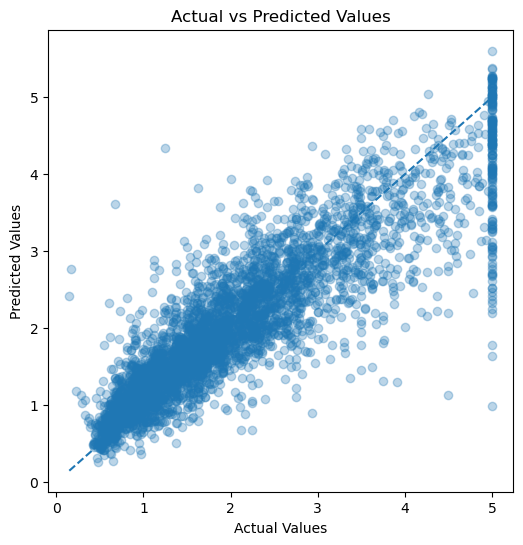

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()